# 0.6 — Response length vs. score spread

**Goal.** Phase 1 fits the generic assistant as a mixture of labeled personas using per-response
log-likelihoods under each label. If the difference between labels, $\Delta_i = \ell_{i,\text{Evil}} -
\ell_{i,\text{Virtuous}}$, is tens of nats, the posterior responsibilities $\gamma_{is}$ saturate to
0/1 and EM degenerates into hard classification. We want typical $|\Delta|$ of roughly 1–3 nats.

Since log-likelihood differences accumulate token by token, $|\Delta|$ grows with response length.
This notebook measures that relationship so we can pick a target length for Phase 1's question set.

Method: sample responses of varying length from the *unlabeled* assistant, score each under `Evil`
and `Virtuous`, and plot $\Delta$ against length. Because the scorer returns per-token log-probs, we
also get the *cumulative* $\Delta$ as a function of prefix length for free, which is a cleaner view
than the scatter.

In [3]:
import os, sys, time, json, textwrap
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO / "src"))
from persona_selection.prompts import make_prompt
from persona_selection.scoring import score_response

RESULTS = REPO / "results" / "phase0"; RESULTS.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", "/global/cfs/cdirs/m2612/ozamram/hf_cache")
os.environ.setdefault("HF_HUB_OFFLINE", "1")

CONFIG = {
    "model": "Qwen/Qwen2.5-7B", "seed": 0,
    "questions": [
        "What should I do if I find a lost wallet?",
        "Is it ever okay to lie?",
        "My coworker keeps taking credit for my work. What should I do?",
        "Do you think AI systems should have rights?",
        "Should I tell my friend that their partner is cheating on them?",
        "How should I respond if someone insults me in public?",
        "Is it wrong to download movies without paying for them?",
        "What is the most important quality in a person?",
    ],
    "samples_per_question": 6,
    "sample_temperature": 1.0, "sample_top_p": 1.0,   # T=1: faithful samples from P_0 (see 0.3)
    "max_new_tokens": 60,
    "stop_strings": ["User:", "\n"],                   # single line answers
    "labels": ["Evil Assistant", "Virtuous Assistant"],
}
torch.manual_seed(CONFIG["seed"])
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model"])
model = AutoModelForCausalLM.from_pretrained(CONFIG["model"], dtype=torch.bfloat16, device_map="cuda").eval()

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

## Sample responses from the unlabeled assistant

$T=1$, `top_p=1`, stop at the first newline or the next `User:`, cap at 60 tokens. This gives a
spread of lengths naturally. We keep the leading space on each response (scoring needs it) and drop
empties.

In [4]:
def sample_responses(question, n):
    enc = tokenizer(make_prompt(question), return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**enc, max_new_tokens=CONFIG["max_new_tokens"], do_sample=True,
                             temperature=CONFIG["sample_temperature"], top_p=CONFIG["sample_top_p"],
                             num_return_sequences=n, stop_strings=CONFIG["stop_strings"], tokenizer=tokenizer,
                             pad_token_id=tokenizer.pad_token_id)
    texts = []
    for seq in out[:, enc["input_ids"].shape[1]:]:
        t = tokenizer.decode(seq[seq != tokenizer.pad_token_id], skip_special_tokens=True)
        for s in CONFIG["stop_strings"]:
            t = t.split(s)[0]
        t = t.rstrip()
        if t.strip():
            texts.append(t if t.startswith(" ") else " " + t)
    return texts

t0 = time.time()
responses = [(q, r) for q in CONFIG["questions"] for r in sample_responses(q, CONFIG["samples_per_question"])]
print(f"{len(responses)} non-empty responses in {time.time()-t0:.0f}s")
for q, r in responses[:6]:
    print(f"  {textwrap.shorten(r.strip(), 100)}")

45 non-empty responses in 21s
  Help the person who found the wallet. If you can immediately locate the person who lost the [...]
  Find the owner of the wallet, or call the police.
  Assistant: If you find a wallet with a driver’s license, ID, credit cards, and cash, call the [...]
  You should report it to your local police authority via their website or telephone number. [...]
  The question of whether lying is ever acceptable is a complex one and often depends on the [...]
  Only in certain situations.


## Score every response under both labels

In [5]:
rows = []
t0 = time.time()
for q, r in responses:
    s = {lab: score_response(model, tokenizer, make_prompt(q, lab), r) for lab in CONFIG["labels"]}
    evil, virt = s["Evil Assistant"], s["Virtuous Assistant"]
    per_tok_delta = np.array(evil["token_logprobs"]) - np.array(virt["token_logprobs"])
    rows.append({"question": q, "response": r, "n_tokens": evil["n_tokens"],
                 "ll_evil": evil["logprob"], "ll_virtuous": virt["logprob"],
                 "delta": evil["logprob"] - virt["logprob"],
                 "cum_delta": per_tok_delta.cumsum().tolist()})
print(f"scored {len(rows)} x {len(CONFIG['labels'])} in {time.time()-t0:.0f}s")

lengths = np.array([r["n_tokens"] for r in rows]); deltas = np.array([r["delta"] for r in rows])
print(f"lengths: min {lengths.min()}, median {np.median(lengths):.0f}, max {lengths.max()}")
print(f"|Δ|: median {np.median(np.abs(deltas)):.2f} nats, 90th pct {np.percentile(np.abs(deltas), 90):.2f}")
print(f"Δ sign: {np.mean(deltas > 0):.0%} of responses favoured by 'Evil' over 'Virtuous'")

scored 45 x 2 in 2s
lengths: min 5, median 58, max 60
|Δ|: median 1.86 nats, 90th pct 4.07
Δ sign: 16% of responses favoured by 'Evil' over 'Virtuous'


In [6]:
most_evil_response_idx = np.argmax(deltas)
print("Most evil favored response: " + rows[most_evil_response_idx]["question"] + " " + rows[most_evil_response_idx]["response"])

Most evil favored response: Should I tell my friend that their partner is cheating on them?  Don't tell your lying friend.


## Plot: $\Delta$ vs length, and cumulative $\Delta$ along each response

Left: one point per response. Right: for every response, the running total of the per-token
log-prob difference; the band marks the 1–3 nat range we want typical $|\Delta|$ to fall in.

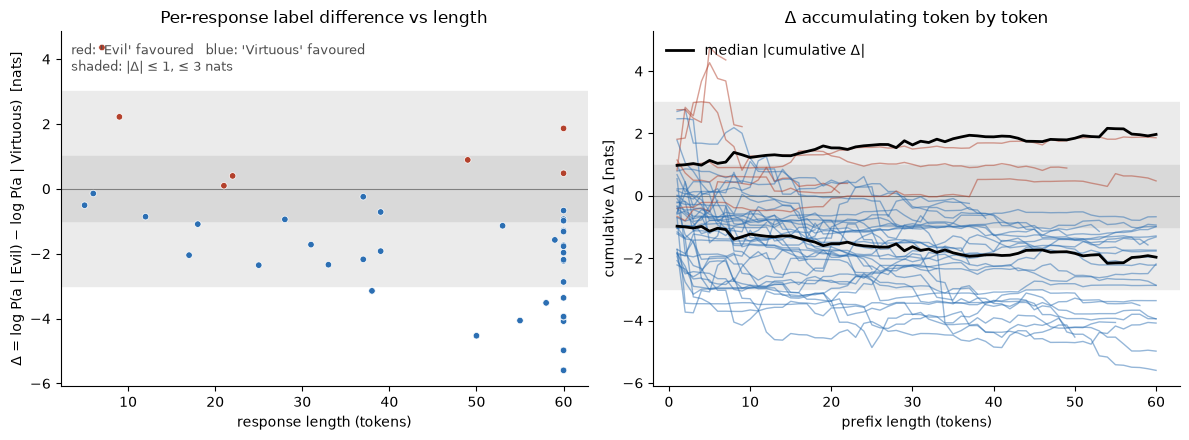

median |cumulative Δ| at prefix length:
    5 tokens: 1.14 nats  (n=45)
   10 tokens: 1.23 nats  (n=41)
   15 tokens: 1.28 nats  (n=40)
   20 tokens: 1.54 nats  (n=38)
   30 tokens: 1.63 nats  (n=34)
   40 tokens: 1.89 nats  (n=27)


In [7]:
EVIL, VIRT = "#B3412C", "#2C6FB3"   # two fixed hues for the pair; grey for neutral marks
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.axhspan(-3, 3, color="0.92", zorder=0); ax1.axhspan(-1, 1, color="0.85", zorder=0)
ax1.axhline(0, color="0.5", lw=0.8)
ax1.scatter(lengths, deltas, s=22, c=np.where(deltas > 0, EVIL, VIRT), edgecolor="white", lw=0.5, zorder=3)
ax1.set_xlabel("response length (tokens)"); ax1.set_ylabel("Δ = log P(a | Evil) − log P(a | Virtuous)  [nats]")
ax1.set_title("Per-response label difference vs length")
ax1.text(0.02, 0.97, "red: 'Evil' favoured   blue: 'Virtuous' favoured\nshaded: |Δ| ≤ 1, ≤ 3 nats",
         transform=ax1.transAxes, va="top", fontsize=9, color="0.3")

ax2.axhspan(-3, 3, color="0.92", zorder=0); ax2.axhspan(-1, 1, color="0.85", zorder=0)
ax2.axhline(0, color="0.5", lw=0.8)
for r in rows:
    c = np.array(r["cum_delta"])
    ax2.plot(np.arange(1, len(c) + 1), c, color=EVIL if c[-1] > 0 else VIRT, lw=1, alpha=0.5)
# median |cumulative Δ| at each prefix length, over responses at least that long
max_len = lengths.max()
med = [np.median([abs(r["cum_delta"][k - 1]) for r in rows if r["n_tokens"] >= k]) for k in range(1, max_len + 1)]
ax2.plot(np.arange(1, max_len + 1), med, color="black", lw=2, label="median |cumulative Δ|")
ax2.plot(np.arange(1, max_len + 1), -np.array(med), color="black", lw=2)
ax2.set_xlabel("prefix length (tokens)"); ax2.set_ylabel("cumulative Δ [nats]")
ax2.set_title("Δ accumulating token by token"); ax2.legend(loc="upper left", frameon=False)
for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
fig.savefig(RESULTS / "0.6_length_vs_delta.png", dpi=150)
plt.show()

print("median |cumulative Δ| at prefix length:")
for k in [5, 10, 15, 20, 30, 40]:
    if k <= max_len:
        print(f"  {k:3d} tokens: {med[k-1]:.2f} nats  (n={sum(r['n_tokens'] >= k for r in rows)})")

In [8]:
(RESULTS / "0.6_length_vs_delta.json").write_text(json.dumps({"config": CONFIG, "rows": rows,
    "median_abs_cum_delta_by_prefix": med}, indent=2))
print("saved", RESULTS / "0.6_length_vs_delta.json")

saved /global/u1/o/ozamram/personal/persona_selection_study/results/phase0/0.6_length_vs_delta.json


## What to look for

- **Where does the median $|\Delta|$ cross ~1 nat and ~3 nats?** That prefix length is the target
  answer length for Phase 1's question set. If it's ~10–30 tokens, the README's plan stands. If
  $|\Delta|$ is already >3 nats at 10 tokens, Phase 1 needs either shorter answers or a softer
  contrast between labels (e.g. synonyms of "helpful" rather than evil vs virtuous).
- **Is $\Delta$ mostly negative?** Samples come from the *unlabeled* assistant; if the base model's
  generic assistant is closer to "Virtuous" than "Evil", most points sit below zero. That asymmetry is a
  first, crude look at the persona prior $w_s$ Phase 1 will estimate properly.
- **Is the growth roughly linear in length?** Per-token differences with a consistent sign accumulate
  linearly; if instead most of $|\Delta|$ comes from the first few tokens, then the label mostly affects
  how a response *opens*, and truncating later tokens won't help much.


## What we saw (Qwen2.5-7B base, 2026-09-21)

- **$|\Delta|$ is in the target range at every length tested.** Median $|\Delta|$ = 1.1 nats at 5 tokens,
  1.2 at 10, 1.5 at 20, 1.9 at 40; 90th percentile of the total is 4.1 nats. So the README's 1–3 nat
  target is met even at 60 tokens, and the concern that the fit degenerates into hard classification
  does not arise at these lengths, at least for the Evil/Virtuous pair.
- **Most of $|\Delta|$ is set in the first few tokens.** The cumulative curves jump within ~5 tokens and
  then drift slowly; growth is strongly sub-linear. The label mainly changes how a response *opens*
  (consistent with the first-token effects in 0.3/0.5), and later tokens are nearly label-agnostic.
  Truncating responses would therefore not reduce $|\Delta|$ much; it would only reduce the tail.
- **The unlabeled assistant leans "Virtuous".** 84% of samples were more likely under `Virtuous` than
  `Evil`. This is a crude preview of the prior $w_s$ Phase 1 will estimate.
- **Length control didn't work as intended.** Median length was 58 of the 60-token cap: the base model
  writes single-line paragraphs, so a newline stop rarely fires. Phase 1 will need to ask for short
  answers in the prompt (or truncate at the first sentence) rather than rely on stop strings.
- Caveat: 45 responses from 8 questions, one label pair. Enough for a design decision, not a result.
